In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/car-price.csv")

In [2]:
df.shape

(4340, 8)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4340 non-null   str    
 1   year           4297 non-null   float64
 2   selling_price  4340 non-null   int64  
 3   km_driven      4167 non-null   float64
 4   fuel           4254 non-null   str    
 5   seller_type    4275 non-null   str    
 6   transmission   4340 non-null   str    
 7   owner          4254 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 271.4 KB


In [13]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007.0,60000,70000.0,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007.0,135000,50000.0,Petrol,Individual,Manual,NaN
2,Hyundai Verna 1.6 SX,2012.0,600000,100000.0,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017.0,250000,46000.0,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014.0,450000,141000.0,Diesel,Individual,Manual,Second Owner


In [15]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='str')

In [17]:
df.describe()

,year,selling_price,km_driven
count,4297.000000,4.340000e+03,4167.000000
mean,2013.087736,5.041273e+05,66237.198224
std,4.219918,5.785487e+05,46635.456187
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [18]:
df['fuel'].value_counts()

fuel
Diesel      2116
Petrol      2077
CNG           38
LPG           22
Electric       1
Name: count, dtype: int64

In [19]:
df['seller_type'].value_counts()

seller_type
Individual          3198
Dealer               976
Trustmark Dealer     101
Name: count, dtype: int64

In [20]:
df['transmission'].value_counts()

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

In [21]:
df['owner'].value_counts()

owner
First Owner             2771
Second Owner            1084
Third Owner              302
Fourth & Above Owner      80
Test Drive Car            17
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

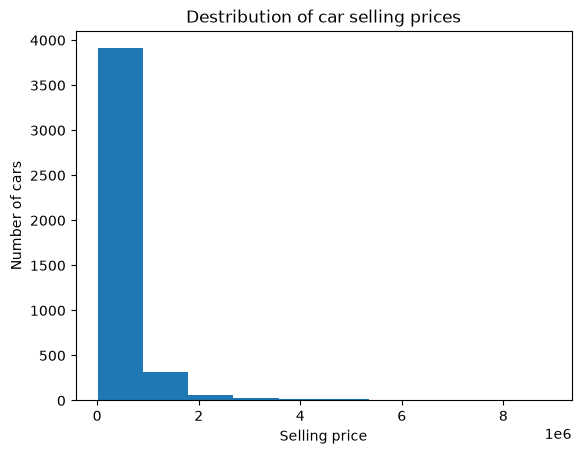

In [25]:
plt.hist(df['selling_price'])
plt.xlabel("Selling price")
plt.ylabel("Number of cars")
plt.title("Destribution of car selling prices")
plt.show

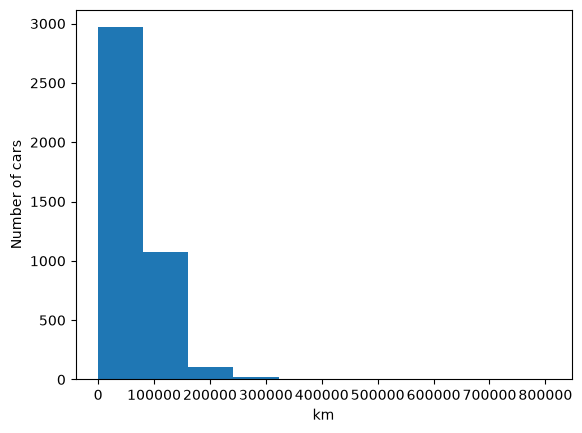

In [29]:
plt.hist(df['km_driven'])
plt.show()

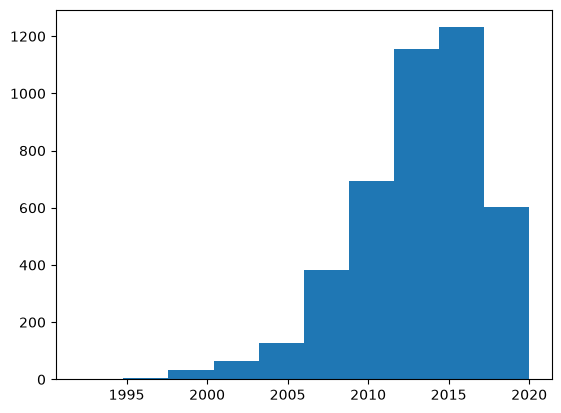

In [30]:
plt.hist(df['year'])
plt.show()

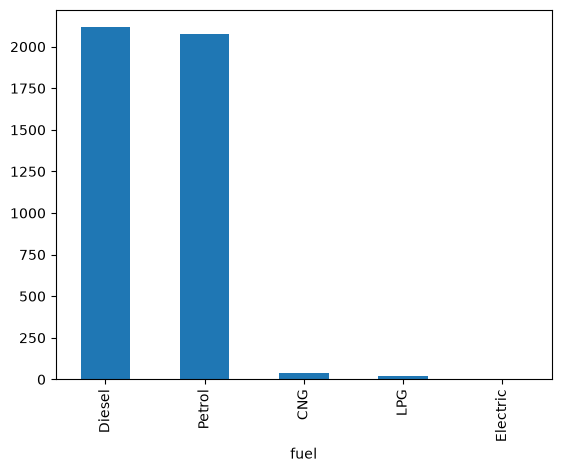

In [31]:
df['fuel'].value_counts().plot(kind="bar")
plt.show()

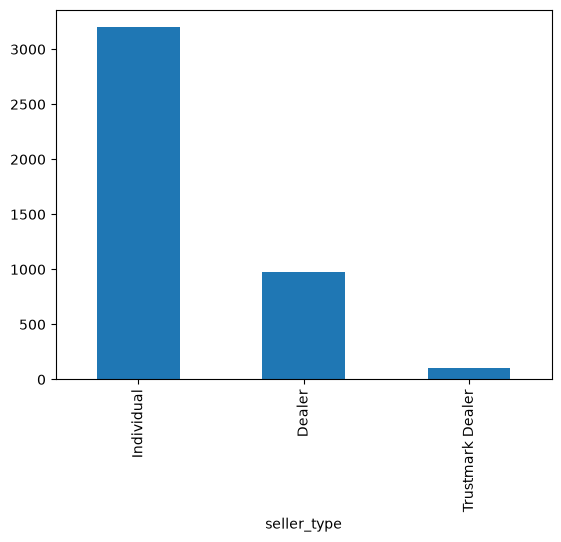

In [32]:
df['seller_type'].value_counts().plot(kind="bar")
plt.show()

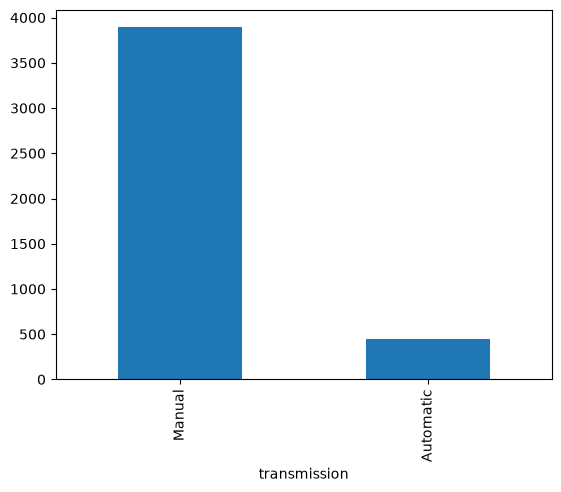

In [33]:
df['transmission'].value_counts().plot(kind="bar")
plt.show()

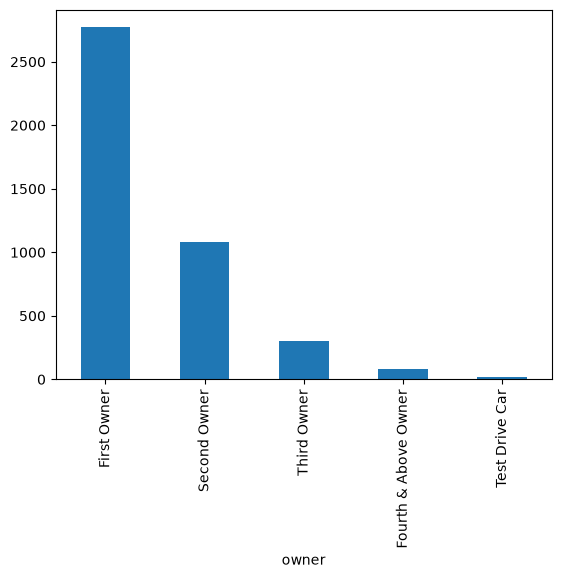

In [34]:
df['owner'].value_counts().plot(kind="bar")
plt.show()

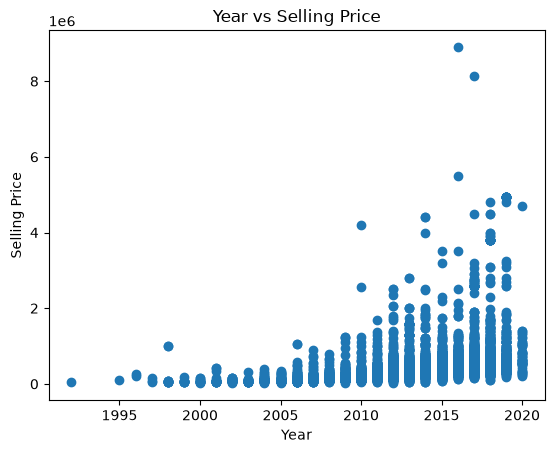

In [36]:
plt.scatter(df["year"], df["selling_price"])
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.title("Year vs Selling Price")
plt.show()

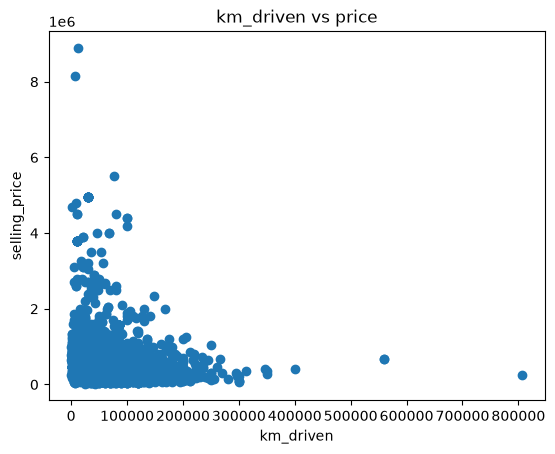

In [37]:
plt.scatter(df['km_driven'], df['selling_price'])
plt.xlabel('km_driven')
plt.ylabel('selling_price')
plt.title('km_driven vs price')
plt.show()

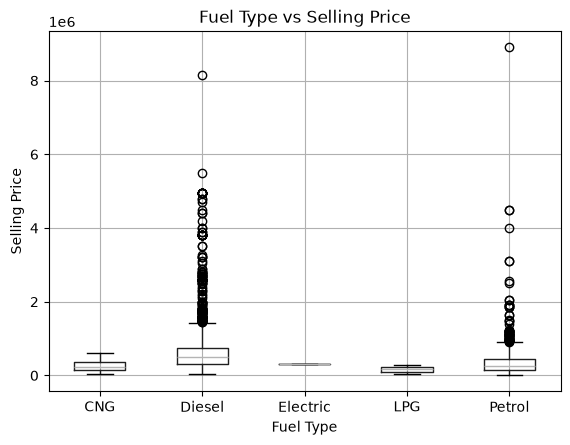

In [49]:
df.boxplot(column="selling_price", by="fuel")


plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.title("Fuel Type vs Selling Price")
plt.suptitle("")
plt.show()

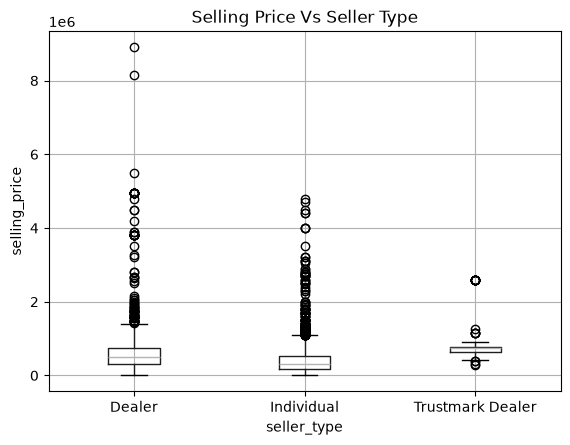

In [50]:
df.boxplot(column='selling_price', by='seller_type')


plt.xlabel('seller_type')
plt.ylabel('selling_price')
plt.title('Selling Price Vs Seller Type')
plt.suptitle("")
plt.show()

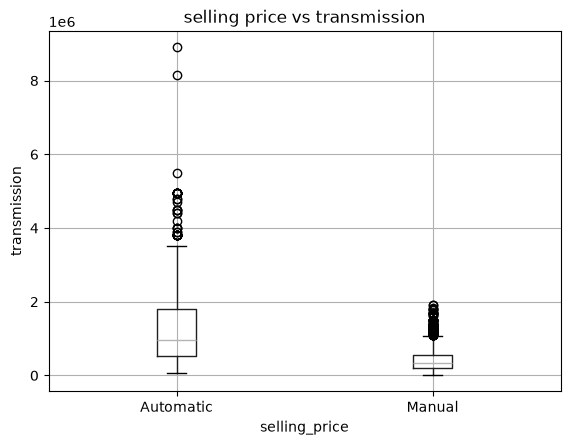

In [51]:
df.boxplot(column='selling_price', by='transmission')

plt.xlabel('selling_price')
plt.ylabel('transmission')
plt.title('selling price vs transmission')
plt.suptitle("")
plt.show()

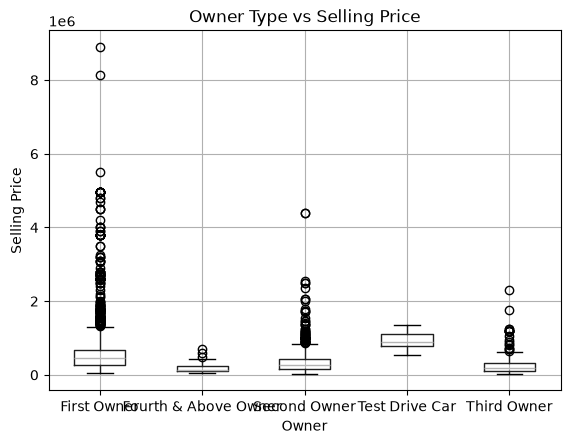

In [52]:
df.boxplot(column="selling_price", by="owner")

plt.xlabel("Owner")
plt.ylabel("Selling Price")
plt.title("Owner Type vs Selling Price")
plt.suptitle("")
plt.show()

In [4]:
firts_owner = df[df["owner"] == "First Owner"]

q1 = firts_owner['selling_price'].quantile(0.25)
q3 = firts_owner['selling_price'].quantile(0.75)


print(q1)
print(q3)
iqr = q3 - q1
print(iqr)

upper_boundry = q3 + 1.5 * iqr
print(upper_boundry)

260000.0
680000.0
420000.0
1310000.0


In [3]:
df[["year", "km_driven", "selling_price"]].corr()

,year,km_driven,selling_price
year,1.000000,-0.415963,0.413501
km_driven,-0.415963,1.000000,-0.190745
selling_price,0.413501,-0.190745,1.000000


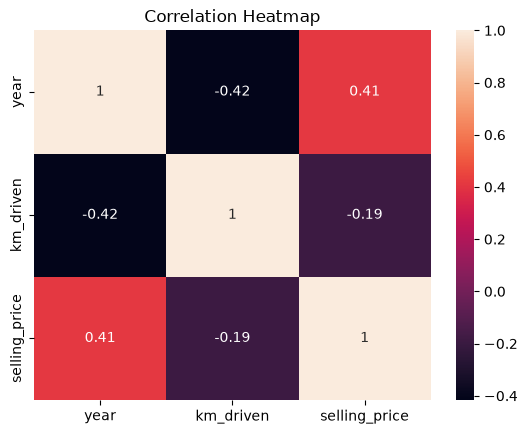

In [4]:
import seaborn as sns

sns.heatmap(
    df[['year', 'km_driven', 'selling_price']].corr(),
    annot=True
)

plt.title('Correlation Heatmap')
plt.show()

In [9]:
df.isna().sum()

name               0
year              43
selling_price      0
km_driven        173
fuel              86
seller_type       65
transmission       0
owner             86
dtype: int64

In [10]:
df[['year', 'km_driven']].median()

year          2014.0
km_driven    60000.0
dtype: float64

In [11]:
df[['fuel', 'seller_type', 'owner']].mode()

,fuel,seller_type,owner
0,Diesel,Individual,First Owner


In [15]:
df['year'] = df['year'].fillna(2014)
df['km_driven'] = df['km_driven'].fillna(60000)


df.isna().sum()

name              0
year              0
selling_price     0
km_driven         0
fuel             86
seller_type      65
transmission      0
owner            86
dtype: int64

In [17]:
df["fuel"] = df["fuel"].fillna("Diesel")
df["seller_type"] = df["seller_type"].fillna("Individual")
df["owner"] = df["owner"].fillna("First Owner")


df.isna().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(668)

In [19]:
df.shape

(4340, 8)

In [20]:
df.nunique()

name             1491
year               27
selling_price     445
km_driven         750
fuel                5
seller_type         3
transmission        2
owner               5
dtype: int64

In [21]:
df = df.drop_duplicates()

df.shape

(3672, 8)

In [22]:
df['selling_price'].quantile([0.25, 0.75])

0.25    200000.0
0.75    600000.0
Name: selling_price, dtype: float64

In [23]:
(df['selling_price'] > 1_200_000).sum()

np.int64(174)

In [24]:
df[df['selling_price'] > 1_200_000][
    ['name', 'year', 'selling_price', 'km_driven', 'fuel']
].sort_values('selling_price', ascending=False).head(10)

,name,year,selling_price,km_driven,fuel
3872,Audi RS7 2015-2019 Sportback Performance,2016.0,8900000,13000.0,Petrol
89,Mercedes-Benz S-Class S 350d Connoisseurs Edition,2017.0,8150000,6500.0,Diesel
3969,Mercedes-Benz GLS 2016-2020 350d 4MATIC,2016.0,5500000,77350.0,Diesel
555,BMW X5 xDrive 30d xLine,2019.0,4950000,30000.0,Diesel
3453,BMW 5 Series 520d Luxury Line,2018.0,4800000,9422.0,Diesel
3883,BMW 5 Series 520d Luxury Line,2019.0,4800000,60000.0,Diesel
963,Audi A5 Sportback,2020.0,4700000,1500.0,Diesel
101,Mercedes-Benz E-Class Exclusive E 200 BSIV,2018.0,4500000,9800.0,Petrol
4047,Volvo XC 90 D5 Inscription BSIV,2017.0,4500000,80000.0,Diesel
539,Mercedes-Benz GL-Class 350 CDI Blue Efficiency,2014.0,4400000,100000.0,Diesel


In [27]:
df['km_driven'].quantile([0.25, 0.75])

0.25    38975.0
0.75    90000.0
Name: km_driven, dtype: float64

In [28]:
(df['km_driven'] > 166_537.5).sum()

np.int64(117)

In [30]:
df[df['km_driven'] > 166_537.5][
    ['name', 'year', 'selling_price', 'km_driven', 'fuel']
].sort_values('km_driven', ascending=False).head(10)

,name,year,selling_price,km_driven,fuel
1243,Maruti Swift VXI BSIII,2009.0,250000,806599.0,Petrol
525,Maruti SX4 S Cross DDiS 320 Delta,2016.0,665000,560000.0,Diesel
3679,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,2006.0,400000,400000.0,Diesel
2394,Toyota Innova 2.5 V Diesel 8-seater,2009.0,350000,350000.0,Diesel
69,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,2010.0,280000,350000.0,Diesel
3718,Toyota Innova 2.5 GX 8 STR BSIV,2009.0,420000,347089.0,Diesel
1674,Volkswagen Jetta 2.0 TDI Comfortline,2011.0,350000,312000.0,Diesel
3646,Toyota Innova 2.5 G (Diesel) 8 Seater BS IV,2006.0,229999,300000.0,Diesel
3898,Tata Indica GLS BS IV,2010.0,90000,300000.0,Petrol
3994,Tata Indica GLS BS IV,2010.0,75000,300000.0,Petrol


In [31]:
df['year'].quantile([0.25, 0.75])

0.25    2010.0
0.75    2016.0
Name: year, dtype: float64

In [32]:
(df['year'] < 2001).sum()

np.int64(37)

In [33]:
df[df['year'] < 2001][
    ['name', 'year', 'selling_price', 'km_driven', 'fuel']
].sort_values('year').head(10)

,name,year,selling_price,km_driven,fuel
3334,Maruti 800 AC BSII,1992.0,50000,100000.0,Petrol
631,Maruti Gypsy E MG410W ST,1995.0,95000,100000.0,Petrol
2972,Mahindra Jeep MM 540,1996.0,200000,60000.0,Diesel
61,Mahindra Jeep CL 500 MDI,1996.0,250000,35000.0,Diesel
1669,Mahindra Jeep CL 500 MDI,1997.0,150000,120000.0,Diesel
3550,Maruti Esteem AX,1997.0,79000,70000.0,Petrol
3661,Maruti 800 Std,1997.0,50000,80000.0,Petrol
1699,Maruti Omni 5 Str STD LPG,1998.0,50000,35000.0,LPG
3371,Honda City 1.3 EXI,1998.0,85000,120000.0,Petrol
3532,Maruti Zen LXI,1998.0,80000,120000.0,Petrol


In [34]:
df.nlargest(10, "km_driven")[
    ["name", "year", "selling_price", "km_driven", "fuel"]
]

,name,year,selling_price,km_driven,fuel
1243,Maruti Swift VXI BSIII,2009.0,250000,806599.0,Petrol
525,Maruti SX4 S Cross DDiS 320 Delta,2016.0,665000,560000.0,Diesel
3679,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,2006.0,400000,400000.0,Diesel
69,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,2010.0,280000,350000.0,Diesel
2394,Toyota Innova 2.5 V Diesel 8-seater,2009.0,350000,350000.0,Diesel
3718,Toyota Innova 2.5 GX 8 STR BSIV,2009.0,420000,347089.0,Diesel
1674,Volkswagen Jetta 2.0 TDI Comfortline,2011.0,350000,312000.0,Diesel
1101,Tata Indica DLS,2006.0,85000,300000.0,Diesel
3646,Toyota Innova 2.5 G (Diesel) 8 Seater BS IV,2006.0,229999,300000.0,Diesel
3898,Tata Indica GLS BS IV,2010.0,90000,300000.0,Petrol


In [35]:
df['name'].nunique()

1491

In [4]:
X = df[[
    "year",
    "km_driven",
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]]

y = df["selling_price"]

In [37]:
X.shape, y.shape

((3672, 6), (3672,))

In [5]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3472, 6), (868, 6), (3472,), (868,))

In [6]:
numeric_features = ['year', 'km_driven']

categorical_features = [
    'fuel',
    'seller_type',
    'transmission',
    'owner'
]

numeric_features, categorical_features

(['year', 'km_driven'], ['fuel', 'seller_type', 'transmission', 'owner'])

In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [9]:
X_train_processed = preprocessor.fit_transform(X_train)

X_train_processed.shape

(3472, 20)

In [10]:
X_test_processed = preprocessor.transform(X_test)

X_test_processed.shape

(868, 20)